In [ ]:
# Base ----------------------------------------------------
import numpy as np
import pandas as pd

# Neural networks ---------------------------------------
import torch
import torch.nn.functional as F
from transformers import AutoTokenizer, AutoModelForCausalLM

# Viz ------------------------------------------------------
import matplotlib.pyplot as plt

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"

# Text Generation

In contrast with classification tasks, where we compute some probabilites and then predict the class based on them, the generation of a coherent text is a rather challenging task that requires the existence of a decoding method:

 * The decoding is done iteratively and thus involves more computations
 * The quality and diversity of the text produced depends on the choice of the decoding method and its hyperparameters

In this document we will use GPT-2 which, as any other autoregressive or causal language models, is pretrained to estimate the probability $P(y|x)$ of a sequence of tokens $y=y_1, y_2,\dots ,y_t$ given some initial prompt or context text $x=x_1, x_2,\dots , x_n$. This probability is estimated using the chain rule on the conditional probability as

$$
P(y_1\dots y_t|x)=\prod_{t=1}^N P(y_t|y_{<t'}, x)
$$

This formula encodes the reason behind the name "autoregressive" since we predict a token based on all the previous ones, then we append this prediction to the inpput sequence and predict a new token.

The point of all this process is how to select the token at each step, but as usual what we do is to select a model for the conditional probabilities, for example a softmax, i.e.

$$
P(y_t=w_i|y_{<t'}, x)=\text{softmax}(z_{t,i})
$$

and then the estimation is done by picking a $\hat y_t$ such that

$$
\hat y_t=\underset{y_t}{\text{argmax}}\,P(y|x)
$$

There are different decoding schemes

* Greedy search
* Beam search
* Sampling methods
* Top-k and nucleus sampling

But it should be stressed that there is no "best" a-priori method. However we can also say that depending on the task we should focus on some or others, for example, if we want to predict accurate text, or a formal answer, we may rely on a combination of greedy and beam searches, while if we generate large texts that have room for creativity we may move to sampling methods and top-k and nucleus sampling

## Greedy Search Decoding

This is the simplest method and uses the same methodology as any other greedy algorithm, i.e. at each time step just choose the token that locally maximizes the probability. We are going to load the pretrained GPT model, but be careful with the memory usage!

We will use "gpt2-xl", but you can change it to "gpt2" or "gpt" if you have memory/time issues (this takes around 6 minutes with GPU). Actually you should change it to see the differences! The gpt2-xl is the 1.5 billion parameter version of GPT-2 with language modeling head.

In [ ]:
model_name = "gpt2-xl"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name).to(device)

config.json:   0%|          | 0.00/689 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/6.43G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/580 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2-xl
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...47}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Now let's generate some text.

In [ ]:
input_txt = "Madrid is"
input_ids = tokenizer(input_txt, return_tensors="pt")["input_ids"].to(device)   # the type of tensor returned is Pytorch

In [ ]:
iterations = []
n_steps = 16
choices_per_step = 5

with torch.no_grad():
  for _ in range(n_steps):
    iteration = dict()
    iteration["input"] = tokenizer.decode(input_ids[0])
    output = model(input_ids=input_ids)

    # Select logits of the first batch and the last token and apply softmax next_token_logits = output.logits[0, -1, :]
    next_token_logits = output.logits[0, -1, :]
    next_token_probs = torch.softmax(next_token_logits, dim=-1)
    sorted_ids = torch.argsort(next_token_probs, dim=-1, descending=True) # Store tokens with highest probabilities

    for choice_idx in range(choices_per_step):
      token_id = sorted_ids[choice_idx]
      token_prob = next_token_probs[token_id].cpu().numpy()
      token_choice = (
          f"{tokenizer.decode(token_id)} ({100 * token_prob:.2f}%)"
      )
      iteration[f"Choice {choice_idx+1}"] = token_choice
    #Append predicted next token to input
    input_ids = torch.cat([input_ids, sorted_ids[None, 0, None]], dim=-1)
    iterations.append(iteration)

see that the output contains the ids within the vocabulary of the predictions

In [ ]:
output

CausalLMOutputWithCrossAttentions(loss=None, logits=tensor([[[ 3.1343,  4.3211,  1.1495,  ..., -6.2278, -3.7745,  0.9839],
         [ 2.2060,  5.9028,  0.0105,  ..., -6.5983, -4.8841,  3.3339],
         [-0.5106,  2.0818, -1.9198,  ..., -6.8719, -4.6883, -0.7000],
         ...,
         [ 2.4816,  3.1438, -1.5587,  ..., -9.9836, -6.3727,  4.3254],
         [-0.7306,  0.4602, -1.8715,  ..., -7.9619, -5.1916, -1.1067],
         [-0.4877,  0.5115, -2.9677,  ..., -7.3803, -6.0955,  0.1890]]],
       device='cuda:0'), past_key_values=DynamicCache(layers=[DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLayer, DynamicLay

each iteration looks like this

In [ ]:
iteration

{'input': 'Madrid is the capital of Spain. It is the largest city in the country and the',
 'Choice 1': ' largest (15.25%)',
 'Choice 2': ' second (13.24%)',
 'Choice 3': ' most (9.25%)',
 'Choice 4': ' third (5.71%)',
 'Choice 5': ' fourth (5.54%)'}

What this code does is:

 * initialize an empty dictionary that will contain the values computed at each iteration
 * decode the input, i.e. read the tokens' ids and decode the words, place it within the dictionary with key "input"
 * use the model to get the predicted outputs: first the ids, then with the softmax we estimate the probabilities
 * arrange the probabilities from high low and decode the largest probabilities
 * create the data frame with the information for future visualization

the data frame we obtain is the following

In [ ]:
pd.DataFrame(iterations)

,input,Choice 1,Choice 2,Choice 3,Choice 4,Choice 5
0,Madrid is,the (11.91%),a (11.82%),not (4.02%),one (3.08%),in (2.81%)
1,Madrid is the,capital (19.82%),most (6.13%),only (5.43%),second (4.42%),first (4.28%)
2,Madrid is the capital,of (78.36%),city (15.29%),and (4.25%),", (0.64%)",in (0.19%)
3,Madrid is the capital of,Spain (72.59%),the (10.44%),Catalonia (9.99%),Madrid (0.86%),Cast (0.66%)
4,Madrid is the capital of Spain,. (34.86%),and (33.19%),", (20.60%)",'s (1.64%),\n (1.40%)
5,Madrid is the capital of Spain.,It (20.76%),\n (19.58%),The (13.83%),Madrid (4.35%),Its (2.42%)
6,Madrid is the capital of Spain. It,is (62.77%),'s (13.83%),has (9.34%),was (3.65%),also (0.92%)
7,Madrid is the capital of Spain. It is,the (31.45%),located (12.50%),a (11.07%),also (8.50%),one (3.29%)
8,Madrid is the capital of Spain. It is the,largest (18.84%),most (14.07%),country (11.57%),second (8.02%),capital (5.86%)
9,Madrid is the capital of Spain. It is the largest,city (75.05%),and (7.78%),metropolitan (3.83%),Spanish (2.66%),", (2.19%)"


Let's see the value of the last iteration

In [ ]:
iterations[15]

{'input': 'Madrid is the capital of Spain. It is the largest city in the country and the',
 'Choice 1': ' largest (15.25%)',
 'Choice 2': ' second (13.24%)',
 'Choice 3': ' most (9.25%)',
 'Choice 4': ' third (5.71%)',
 'Choice 5': ' fourth (5.54%)'}

This means that the next word it will predict would be "largest", and so on. Note that, for example with "gpt2" the generated sentence was "Madrid is a former member of the Spanish National Congress and a member of the Spanish National"

We have implemented the model from scratch by simple iteration, but `transformers` provides the generate() function that we can easily use

In [ ]:
input_ids = tokenizer(input_txt, return_tensors="pt")["input_ids"].to(device)
output = model.generate(input_ids, max_new_tokens = n_steps, do_sample = False)
print(tokenizer.decode(output[0]))

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Madrid is the capital of Spain. It is the largest city in the country and the largest


which generates the same sentence as before.

There is a famous example of OpenAI's GTP-2 where given the prompt

```{text}
"In a shocking finding, scientist discovered a herd of unicorns living in a remote, previously unexplored valley, in the Andes Mountains. Even more surprising to the researchers was the fact that the unicorns spoke perfect English."
```

The following output was generated

```{text}
"In a shocking finding, scientist discovered a herd of unicorns living in a remote, previously unexplored valley, in the Andes Mountains. Even more
surprising to the researchers was the fact that the unicorns spoke perfect English.

The researchers, from the University of California, Davis, and the University of Colorado, Boulder, were conducting a study on the Andean cloud forest, which is home to the rare species of cloud forest trees.

The researchers were surprised to find that the unicorns were able to communicate with each other, and even with humans.

The researchers were surprised to find that the unicorns were able"
```

Let's see what we can get from the same input!

In [ ]:
max_length = 128
input_txt = 'In a shocking finding, scientist discovered a herd of unicorns\
      living in a remote, previously unexplored valley, in the Andes Mountains. \
        Even more surprising to the researchers was the fact that the unicorns spoke \
            perfect English.\n\n'
input_ids = tokenizer(input_txt, return_tensors="pt")["input_ids"].to(device)
output = model.generate(input_ids, max_length=max_length, do_sample = False)
print(tokenizer.decode(output[0]))

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


In a shocking finding, scientist discovered a herd of unicorns      living in a remote, previously unexplored valley, in the Andes Mountains.         Even more surprising to the researchers was the fact that the unicorns spoke             perfect English.


The researchers, from the University of California, Davis, and the University of Colorado, Boulder, were studying the Andes Mountains in the Andes Mountains of South America when they came across the herd of unicorns.             


## Beam Search Decoding

Instead of decoding the token with the largest probability at each step, beam search keeps track of the top-b most probable tokens, where $b$ refers to the number of beams or partial hypotheses.

The next set of beams are chosen considering all possible next_token extensions of the existing set and selecting the b most likely extensions. The process is repeated until we reach the maximum length or an EOS token, then the most likely sequence is obtained by ranking the $b$ beams according to their log probabilities (just to turn the products into sums). We can visualize this with the image from "Natural Language with Transformers" Tunstall, Werra & Wolf

<br>

![Beam Search](https://drive.google.com/uc?export&id=1MPvLbpqV-hhEY6I0tKdRZhF09ISmA1lS)

In [ ]:
max_length = 64
input_txt = "Madrid is"
input_ids = tokenizer(input_txt, return_tensors="pt")["input_ids"].to(device)
output_beam = model.generate(input_ids, max_length = max_length, num_beams = 5, do_sample=False)
print(tokenizer.decode(output_beam[0]))

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Madrid is the capital of Spain and the largest city in the Iberian Peninsula. It is located on the Mediterranean coast of the Iberian Peninsula, between the Pyrenees Mountains and the Bay of Biscay. It has a population of over 7.5 million people.

History [ edit ]


Can you use it with the OpenAI's prompt? What do you get? And if you change the model?

## Sampling Methods

When factual correctness is less important than the diversit of generated output, for instance in open-domain chichat or story generation, we may use sampling, i.e. we may randomly sample from the probability distribution of the model's outputs over the full vocabulary at each timestep.

$$
P(y_t=w_i|y_{<t'}, x)=\text{softmax}(z_{t,i}) = \frac{exp(z_{t,i})}{\sum_{j=2}^{|V|}exp{(z_{t,j})}}
$$

where $|V|$ denotes the cardinality of the vocabulary. The diversity of the output can be controlled by adding a temperature parameter (this is stolen from physics where these exponential families appear in the Boltzman distribution with a factor 1/KT where K is usualy set to one and T is the temperature).

When $T<<1$ the distribution peaks around the origin and the rare tokens are suppresed. On the other hand, when $T>>1$, the distribution flattens and each token becomes equally likely.

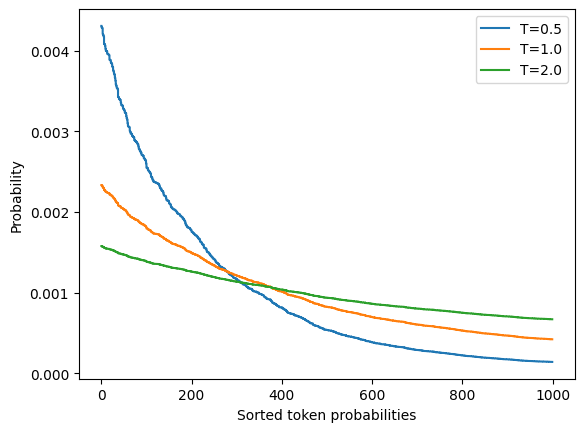

In [ ]:
def softmax(logits, T=1):
    e_x = np.exp(logits / T)
    return e_x / e_x.sum()

logits = np.exp(np.random.random(1000))
sorted_logits = np.sort(logits)[::-1]
x = np.arange(1000)

for T in [0.5, 1.0, 2.0]:
    plt.step(x, softmax(sorted_logits, T), label=f"T={T}")
plt.legend(loc="best")
plt.xlabel("Sorted token probabilities")
plt.ylabel("Probability")
plt.show()

In [ ]:
output_temp = model.generate(input_ids, max_length = max_length, do_sample = True, temperature = 2.0, top_k = 0)
print(tokenizer.decode(output_temp[0]))

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Madrid is madeing malfunction damages)?"), Mer download & other condition questions rule satisfies precipital read asc's beanssh Calculator Par exclusively jury functional tapping crusin hob disruption insist sanitationEat sitn tv Per BDS E coronona Far Strategies aimedBTCAwesome most endure engage Acquisionsumption stoneIlMerit Michael Gold Hate series exceeds


Let's change the temperature of the model... this should allow for a more meaningful output

In [ ]:

output_temp = model.generate(input_ids, max_length = max_length, do_sample = True, temperature = .5, top_k = 0)
print(tokenizer.decode(output_temp[0]))

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


Madrid is one of the most expensive cities in the world. The average cost of a house in Spain in 2016 was €241,000, according to the latest figures from the country's central bank.

But Madrid is also one of the most desirable places in the world to live.

Here are the


Another way to adjust the trade-off between coherence and diversity is to truncate the distribution of the vocabulary. Top-K and Nucleus Sampling are doing this... did you noticed the `top_k` argument?

## Top-k and Nucleus Sampling

These methods are alternatives to the temperature adjustment in which we simply restrict the number of possible tokens from each timestep. In the following graph we see that the probability that we obtain the right word is just 1 in 10 (distribution on the left). The graph on the right is the sumulative sum of probabilities for the first 10K tokens  (out of the 50,257 tokens in GPT2) and it says that there is a 96% of picking any of the 1K tokens with the highest probability.

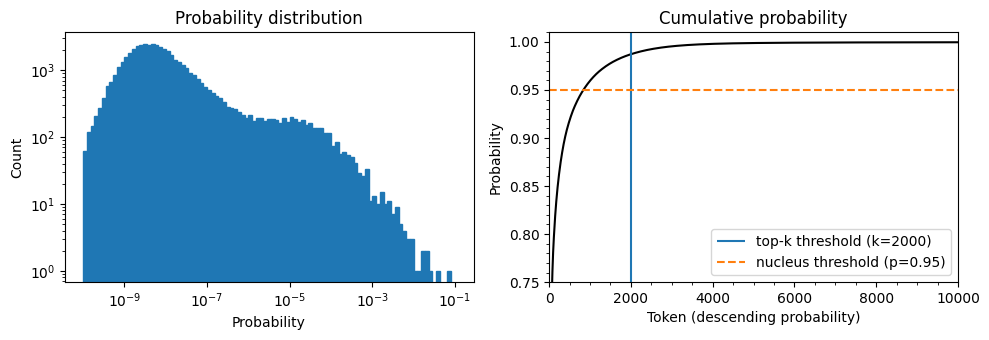

In [ ]:
torch.manual_seed(42)
input_txt = """In a shocking finding, scientist discovered \
a herd of unicorns living in a remote, previously unexplored \
valley, in the Andes Mountains. Even more surprising to the \
researchers was the fact that the unicorns spoke perfect English.\n\n
"""
input_ids = tokenizer(input_txt, return_tensors="pt")["input_ids"].to(device)

with torch.no_grad():
    output = model(input_ids=input_ids)
    next_token_logits = output.logits[:, -1, :]
    probs = F.softmax(next_token_logits, dim=-1).detach().cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

axes[0].hist(probs[0], bins=np.logspace(-10, -1, 100), color="C0", edgecolor="C0")
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_title("Probability distribution")
axes[0].set_xlabel("Probability")
axes[0].set_ylabel("Count")
#axes[0].grid(which="major")

axes[1].plot(np.cumsum(np.sort(probs[0])[::-1]), color="black")
axes[1].set_xlim([0, 10000])
axes[1].set_ylim([0.75, 1.01])
axes[1].set_title("Cumulative probability")
axes[1].set_ylabel("Probability")
axes[1].set_xlabel("Token (descending probability)")
#axes[1].grid(which="major")
axes[1].minorticks_on()
#axes[1].grid(which='minor', linewidth='0.5')
top_k_label = 'top-k threshold (k=2000)'
top_p_label = 'nucleus threshold (p=0.95)'
axes[1].vlines(x=2000, ymin=0, ymax=2, color='C0', label=top_k_label)
axes[1].hlines(y=0.95, xmin=0, xmax=10000, color='C1', label=top_p_label, linestyle='--')
axes[1].legend(loc='lower right')
plt.tight_layout()

Top-p cuts these probabilities by avoiding low-probability choices and only sampling from the k tokens with the highest probability

In [ ]:
output_topk = model.generate(input_ids, max_length = max_length, do_sample=True, top_k=10)
print(tokenizer.decode(output_topk[0]))

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


In a shocking finding, scientist discovered a herd of unicorns living in a remote, previously unexplored valley, in the Andes Mountains. Even more surprising to the researchers was the fact that the unicorns spoke perfect English.


The scientists found that the herd of unicorns had been grazing in an isolated valley for


How do we choose $k$? We can use dynamic cutoff, and then this value is not fixed and we simply choose a horizontal threshold of probabilites

In [ ]:
output_topp = model.generate(input_ids, max_length = max_length, do_sample = True, top_p=0.1)   # change this top_p to see the outputs you get
print(tokenizer.decode(output_topp[0]))

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


In a shocking finding, scientist discovered a herd of unicorns living in a remote, previously unexplored valley, in the Andes Mountains. Even more surprising to the researchers was the fact that the unicorns spoke perfect English.


The researchers, from the University of California, Davis, and the University of Colorado,
